# PCA

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

def reduce_and_plot(data, group_column=None, method='umap'):
    """
    Снижение размерности до 2 компонент и автоклассификация неизвестных точек через KMeans.
    Поддерживаются только методы: PCA, t-SNE, UMAP.
    """
    numeric = data.select_dtypes(include=[np.number])
    numeric = numeric.dropna(axis=1, how='all')
    X = StandardScaler().fit_transform(numeric)

    # 1️⃣ Снижение размерности до 2
    if method == 'pca':
        X_red = PCA(n_components=2).fit_transform(X)

    elif method == 'tsne':
        perplexity = min(50, max(5, len(data)//10))
        X_red = TSNE(n_components=2, perplexity=perplexity, learning_rate=200, init='pca',
                     max_iter=1500, random_state=95).fit_transform(X)

    elif method == 'umap':
        X_red = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.05,
                          metric="cosine", random_state=95).fit_transform(X)

    else:
        raise ValueError("Unknown method. Use 'pca', 'tsne', or 'umap'.")

    # 2️⃣ Назначение цветов по колонке gender
    colors = np.array(["steelblue"]*len(data), dtype=object)  # дефолтный цвет

    if group_column and group_column in data.columns:
        known_mask = data[group_column].notna()
        unique_labels = data.loc[known_mask, group_column].unique()
        label_map = {lbl:i for i, lbl in enumerate(unique_labels)}
        
        cluster_colors = sns.color_palette("tab10", n_colors=len(unique_labels))
        
        for idx, val in enumerate(data[group_column]):
            if pd.notna(val):
                colors[idx] = cluster_colors[label_map[val]]
            else:
                colors[idx] = "lightgray"  # цвет для неизвестного пола

    # 3️⃣ Визуализация
    plt.figure(figsize=(8,6))
    plt.scatter(X_red[:,0], X_red[:,1], c=colors, alpha=0.8)
    plt.title(f"{method.upper()} Projection with KMeans coloring")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()
    
    return X_red

In [ ]:
# PCA
# reduce_and_plot(final_df, group_column="gender", method="pca")
# только UMAP
# reduce_and_plot(final_df, group_column="gender", method="umap")
# t-SNE
# reduce_and_plot(final_df, group_column="gender", method="tsne")


# TSNE

# UMAP

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import seaborn as sns
import matplotlib.pyplot as plt

def reduce_and_plot(data, group_column=None, method='umap', pca_variance=0.95):
    """
    Pipeline:
    1. StandardScaler
    2. PCA (сохранение 95% дисперсии)
    3. TSNE / UMAP / PCA(2D)
    """

    # -------- числовые признаки --------
    numeric = data.select_dtypes(include=[np.number])
    numeric = numeric.dropna(axis=1, how='all')
    numeric = numeric.fillna(numeric.mean())

    # -------- стандартизация --------
    scaler = StandardScaler()
    X = scaler.fit_transform(numeric)

    # -------- PCA 95% --------
    pca = PCA(n_components=pca_variance, random_state=95)
    X_pca = pca.fit_transform(X)

    print(f"PCA components: {X_pca.shape[1]}")
    print(f"Explained variance: {np.sum(pca.explained_variance_ratio_):.3f}")

    # -------- Снижение до 2D --------
    if method == 'pca':
        X_red = PCA(n_components=2).fit_transform(X_pca)

    elif method == 'tsne':
        perplexity = min(50, max(5, len(data)//10))
        X_red = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate=200,
            init='pca',
            max_iter=3000,
            random_state=95
        ).fit_transform(X_pca)

    elif method == 'umap':
        X_red = umap.UMAP(
            n_components=2,
            n_neighbors=20,
            min_dist=0.01,
            metric="cosine",
            random_state=95
        ).fit_transform(X_pca)

    else:
        raise ValueError("Use 'pca', 'tsne', or 'umap'")

    # -------- Цвета по gender --------
    colors = np.array(["lightgray"] * len(data), dtype=object)

    if group_column and group_column in data.columns:
        unique_labels = data[group_column].dropna().unique()
        palette = sns.color_palette("tab10", len(unique_labels))
        label_map = dict(zip(unique_labels, palette))

        for i, val in enumerate(data[group_column]):
            if pd.notna(val):
                colors[i] = label_map[val]

    # -------- Plot --------
    plt.figure(figsize=(10,8))
    plt.scatter(X_red[:,0], X_red[:,1], c=colors, alpha=0.8)

    plt.title(f"{method.upper()} after PCA 95%", fontsize=16)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.show()

    return X_red

In [ ]:
# final_df = pd.read_csv("/home/user/papkamusik/action_folder/features_with_gender_expanded.csv")
final_df = pd.read_csv("/home/user/papkamusik/action_folder/features_177_updated_clean.csv")

# reduce_and_plot(final_df, group_column="gender", method="pca")
# reduce_and_plot(final_df, group_column="gender", method="tsne")
# reduce_and_plot(final_df, group_column="gender", method="umap")

TypeError: auto_reduce_and_evaluate() got an unexpected keyword argument 'method'

In [14]:
import pandas as pd

# загрузка
final_df = pd.read_csv("/home/user/papkamusik/action_folder/features_177_updated.csv")

# убираем строки где gender = "-"
final_df = final_df[final_df["gender"] != "-"]

# если есть NaN и их тоже нужно убрать (рекомендую)
final_df = final_df[final_df["gender"].notna()]

# сохранить обратно
final_df.to_csv("/home/user/papkamusik/action_folder/features_177_updated_clean.csv", index=False)

print("Готово. Новый размер:", final_df.shape)

Готово. Новый размер: (158, 22)


In [3]:
import pandas as pd
import numpy as np

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 0 to 158
Data columns (total 58 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   call_id         158 non-null    int64  
 1   role            158 non-null    object 
 2   f0_mean         158 non-null    float64
 3   f0_median       158 non-null    float64
 4   f0_variance     158 non-null    float64
 5   f0_std          158 non-null    float64
 6   f0_min          158 non-null    float64
 7   f0_max          158 non-null    float64
 8   f0_range        158 non-null    float64
 9   f0_skew         158 non-null    float64
 10  f0_kurtosis     158 non-null    float64
 11  f0_cv           158 non-null    float64
 12  f1_mean         158 non-null    float64
 13  f1_median       158 non-null    float64
 14  f1_variance     158 non-null    float64
 15  f1_std          158 non-null    float64
 16  f1_min          158 non-null    float64
 17  f1_max          158 non-null    float64


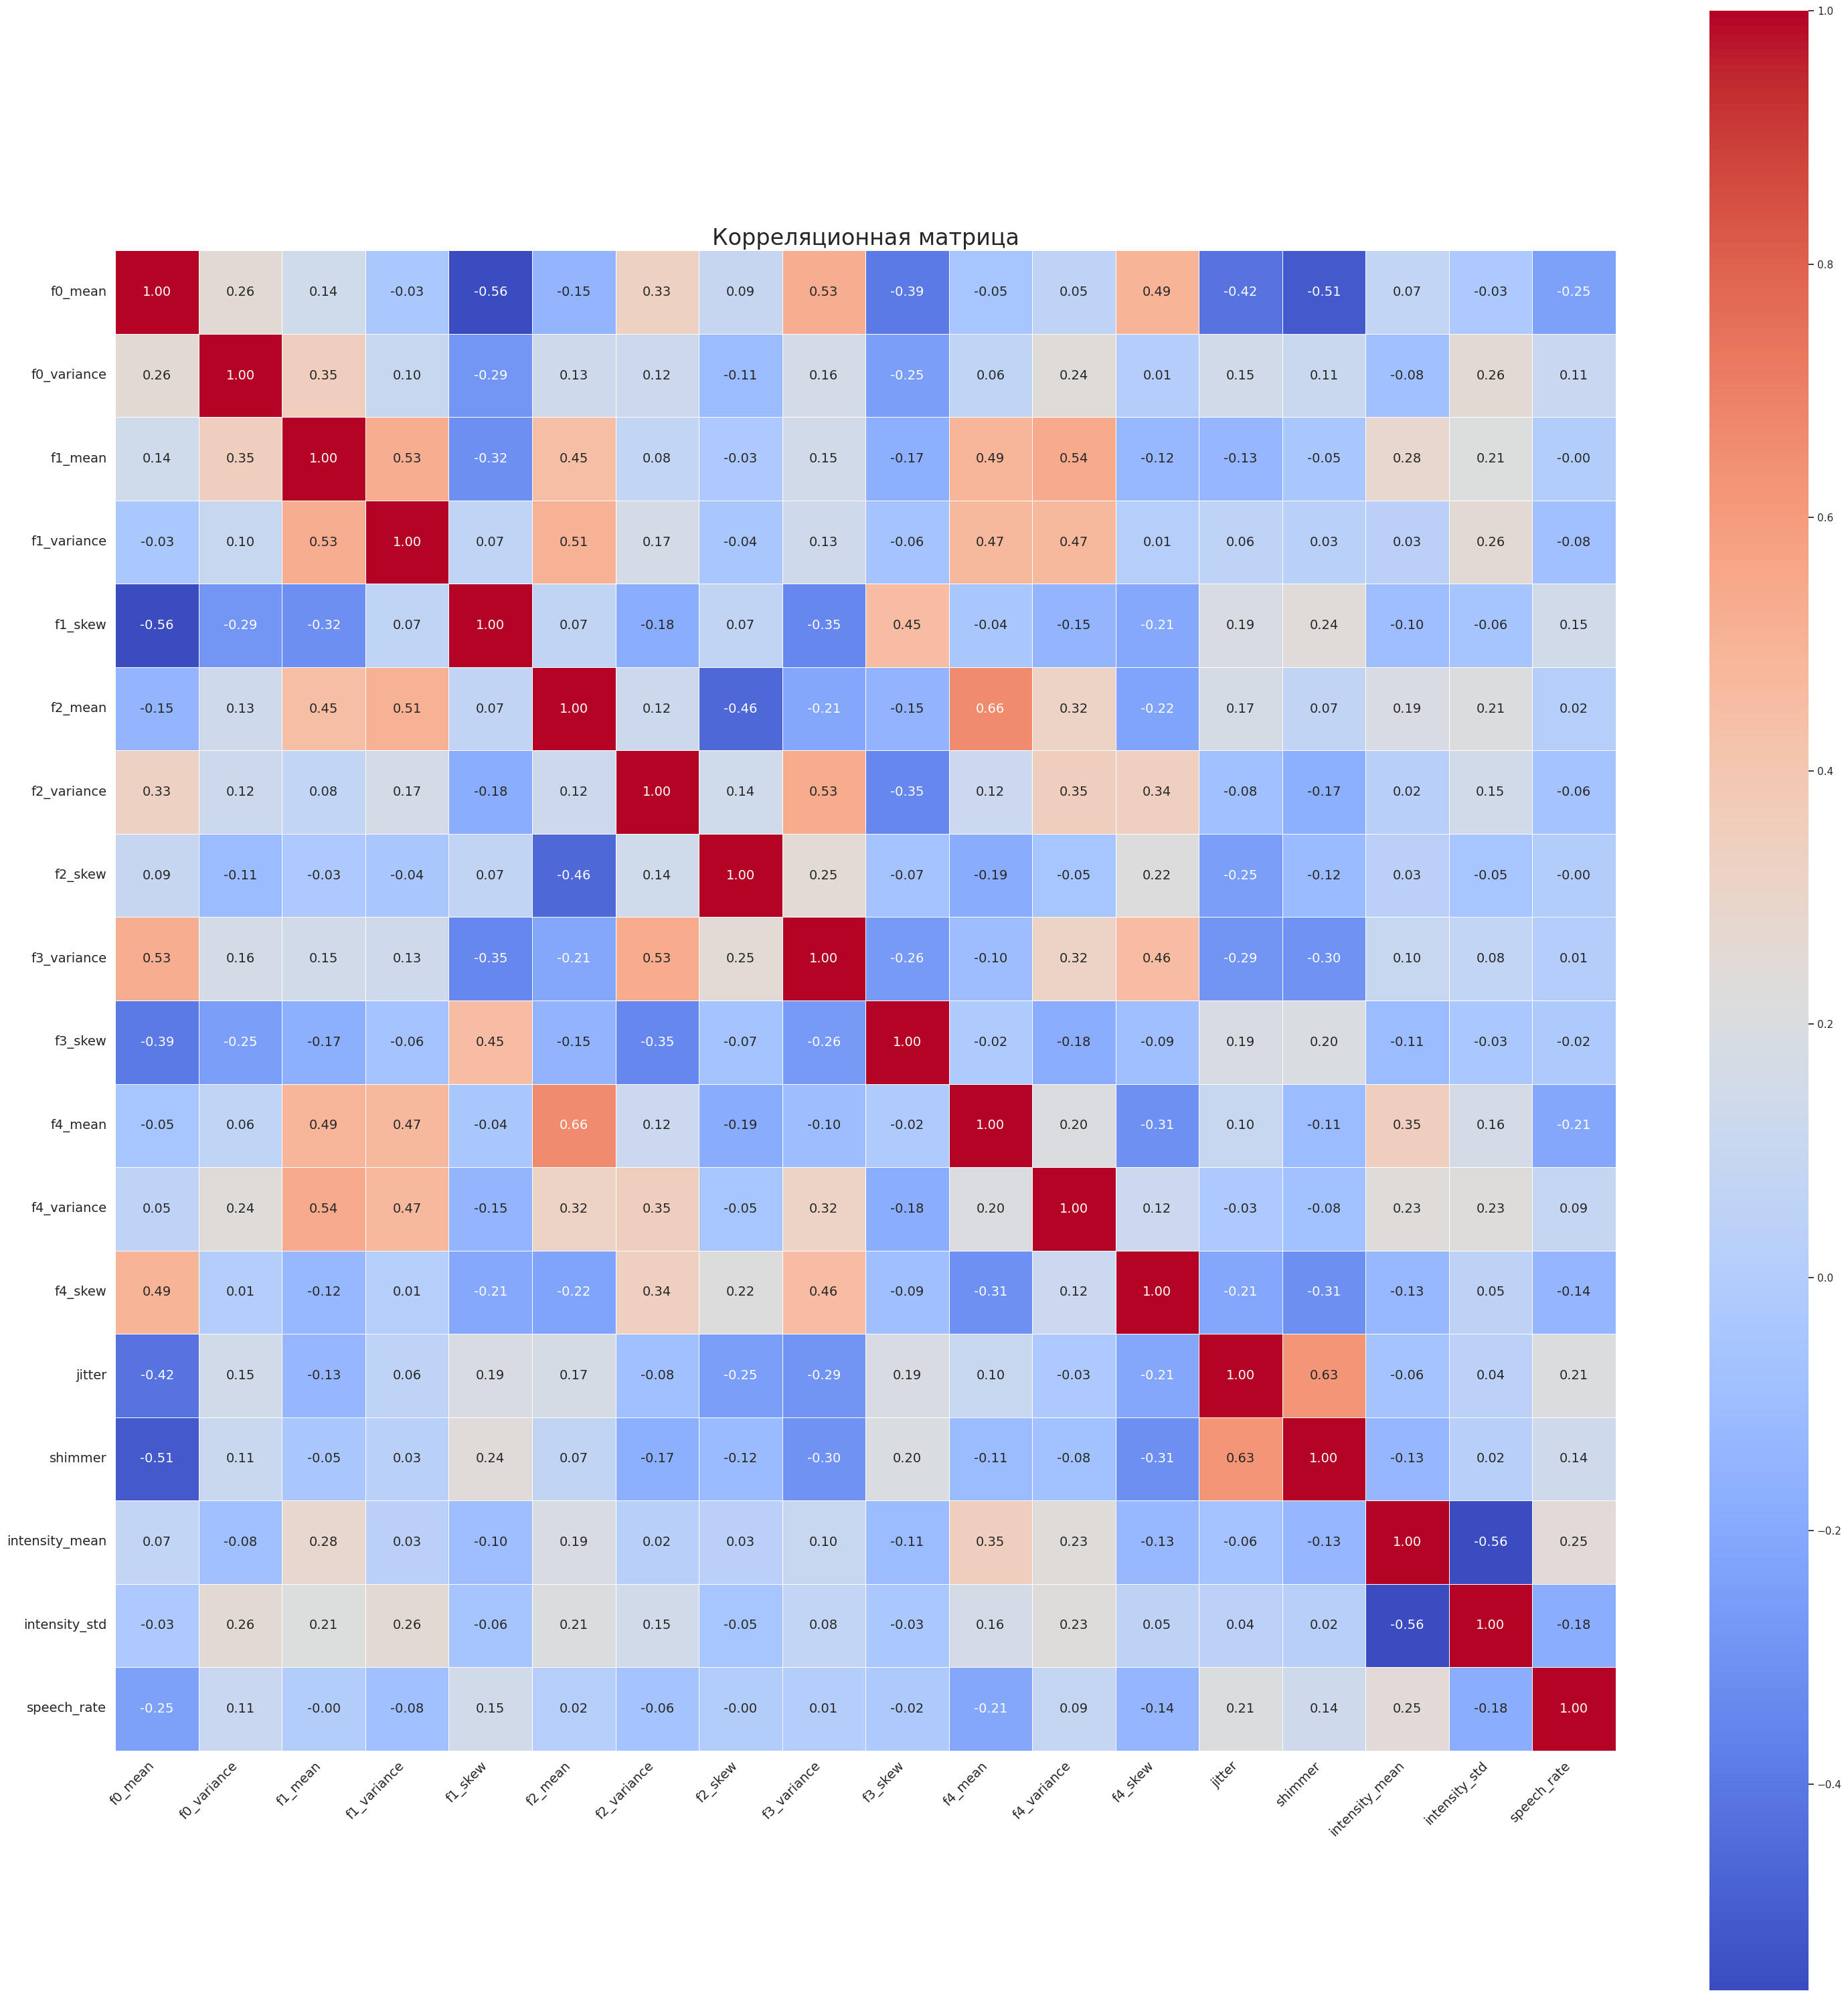

In [18]:
final_df = pd.read_csv("/home/user/papkamusik/action_folder/result_177.csv")
# Удаляем строки, где gender = "-"
final_df = final_df[final_df["sex"] != "-"].reset_index(drop=True)
# final_df = final_df[final_df["role"] != "assistant"].reset_index(drop=True)
final_df=final_df.dropna()
final_df.rename(columns={"sex": "gender"}, inplace=True)

# final_df.sex.unique()
final_df.info()

import matplotlib.pyplot as plt
import seaborn as sns

# -------- выбираем числовые признаки --------

final_df.drop(columns=["call_id","f0_cv","f1_cv","f2_cv","f3_cv","f4_cv","f0_median","f1_median","f2_median","f3_median","f4_median",
                       "f0_range","f1_range","f2_range","f3_range","f4_range","f0_std","f1_std","f2_std","f3_std","f4_std",
                       "f0_min","f0_max","f1_min","f1_max","f2_min","f2_max","f3_min","f3_max","f4_min","f4_max","f1_kurtosis",
                       "f2_kurtosis","f3_kurtosis","f4_kurtosis","f0_kurtosis","f3_mean","f0_skew"], inplace=True)
numeric = final_df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()
# -------- корреляционная матрица --------
plt.figure(figsize=(30,30))  # увеличили размер

sns.set(font_scale=1)  # увеличили шрифт
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",              # округление чисел
    cmap="coolwarm",
    square=True,            # квадратные клетки
    linewidths=0.7,         # линии между клетками
    annot_kws={"size": 14}  # размер чисел внутри
)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.title("Корреляционная матрица", fontsize=24)
plt.tight_layout()
plt.show()


# убираем дубликаты и диагональ
upper = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape), k=0).astype(bool))

# выбираем пары с корреляцией > 0.7
high_corr = [(col1, col2, upper.loc[col1, col2]) 
             for col1 in upper.columns 
             for col2 in upper.columns 
             if pd.notnull(upper.loc[col1, col2]) and upper.loc[col1, col2] > 0.7]

# выводим
for col1, col2, val in high_corr:
    print(f"{col1} ↔ {col2}: {val:.2f}")

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.simplefilter("ignore")


def auto_reduce_and_evaluate(data, group_column="gender", pca_variance=0.95):
    """
    Pipeline:
    1. StandardScaler
    2. PCA (сохранение pca_variance)
    3. TSNE / UMAP перебор параметров
    4. Сбор метрик (silhouette_score)
    5. Построение графиков для лучших комбинаций в 2D и 3D
    """

    numeric = data.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    X = StandardScaler().fit_transform(numeric)

    # -------- PCA 95% --------
    pca = PCA(n_components=pca_variance, random_state=95)
    X_pca = pca.fit_transform(X)
    print(f"PCA components: {X_pca.shape[1]}")
    print(f"Explained variance: {np.sum(pca.explained_variance_ratio_):.3f}")

    # -------- Цвета по gender --------
    labels = data[group_column].astype(str)
    palette = sns.color_palette("tab10", len(labels.unique()))
    color_map = dict(zip(labels.unique(), palette))
    colors = labels.map(color_map)

    results = []

    # -------- TSNE перебор --------
    tsne_perplexities = [5, 10, 15, 20, 30, 40, 45, 50]
    tsne_learning_rates = [50, 75, 100, 120, 150, 170, 200, 230, 260, 300, 400]  # расширим диапазон

    for p in tsne_perplexities:
        for lr in tsne_learning_rates:
            model = TSNE(n_components=2, perplexity=p, learning_rate=lr, init='pca',
                         max_iter=3000, random_state=95)
            X_red = model.fit_transform(X_pca)
            try:
                score = silhouette_score(X_red, labels)
            except:
                score = -1
            results.append({
                "method": "PCA+TSNE",
                "param1_name": "perplexity",
                "param1_value": p,
                "param2_name": "learning_rate",
                "param2_value": lr,
                "score": score
            })

    # -------- UMAP перебор --------
    neighbors_list = [5, 10,12,14, 15,16,18, 20,22,24,26,28, 30]
    min_dist_list = [0.001, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1]

    for n in neighbors_list:
        for md in min_dist_list:
            model = umap.UMAP(n_components=2, n_neighbors=n, min_dist=md, random_state=95)
            X_red = model.fit_transform(X_pca)
            try:
                score = silhouette_score(X_red, labels)
            except:
                score = -1
            results.append({
                "method": "PCA+UMAP",
                "param1_name": "n_neighbors",
                "param1_value": n,
                "param2_name": "min_dist",
                "param2_value": md,
                "score": score
            })

    results_df = pd.DataFrame(results)
    print("\n==============================")
    print("ALL RESULTS")
    print("==============================")
    print(results_df.sort_values("score", ascending=False))

    # -------- Лучшие комбинации --------
    best_tsne = results_df[results_df["method"]=="PCA+TSNE"].sort_values("score", ascending=False).iloc[0]
    best_umap = results_df[results_df["method"]=="PCA+UMAP"].sort_values("score", ascending=False).iloc[0]

    print("\n==============================")
    print("BEST TSNE")
    print(best_tsne)
    print("\n==============================")
    print("BEST UMAP")
    print(best_umap)

    # -------- Функция для построения --------
    def plot_2d_3d(model_2d, model_3d, X_source, title):
        # -------- 2D --------
        X_2d = model_2d.fit_transform(X_source)
        plt.figure(figsize=(10,8))
        plt.scatter(X_2d[:,0], X_2d[:,1], c=colors)
        plt.title(f"{title} 2D")
        plt.show()

        # -------- 3D --------
        X_3d = model_3d.fit_transform(X_source)
        fig = plt.figure(figsize=(10,8))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=colors)
        plt.title(f"{title} 3D")
        plt.show()

  # -------- Построение лучших --------
    tsne_best_2d = TSNE(
        n_components=2,
        perplexity=int(best_tsne["param1_value"]),
        learning_rate=int(best_tsne["param2_value"]),
        init='pca',
        max_iter=3000,
        random_state=95
    )
    tsne_best_3d = TSNE(
        n_components=3,
        perplexity=int(best_tsne["param1_value"]),
        learning_rate=int(best_tsne["param2_value"]),
        init='pca',
        max_iter=3000,
        random_state=95
    )
  
    umap_best_2d = umap.UMAP(
        n_components=2,
        n_neighbors=int(best_umap["param1_value"]),
        min_dist=float(best_umap["param2_value"]),
        random_state=95
    )
    umap_best_3d = umap.UMAP(
        n_components=3,
        n_neighbors=int(best_umap["param1_value"]),
        min_dist=float(best_umap["param2_value"]),
        random_state=95
    )

    plot_2d_3d(tsne_best_2d, tsne_best_3d, X_pca, "BEST PCA + TSNE")
    plot_2d_3d(umap_best_2d, umap_best_3d, X_pca, "BEST PCA + UMAP")
    
    return results_df

PCA components: 14
Explained variance: 0.964

ALL RESULTS
       method  param1_name  param1_value    param2_name  param2_value  \
35   PCA+TSNE   perplexity            20  learning_rate        100.00   
25   PCA+TSNE   perplexity            15  learning_rate        120.00   
165  PCA+UMAP  n_neighbors            24       min_dist          0.05   
23   PCA+TSNE   perplexity            15  learning_rate         75.00   
171  PCA+UMAP  n_neighbors            26       min_dist          0.03   
..        ...          ...           ...            ...           ...   
188  PCA+UMAP  n_neighbors            30       min_dist          0.04   
9    PCA+TSNE   perplexity             5  learning_rate        300.00   
10   PCA+TSNE   perplexity             5  learning_rate        400.00   
54   PCA+TSNE   perplexity            30  learning_rate        400.00   
43   PCA+TSNE   perplexity            20  learning_rate        400.00   

        score  
35   0.383384  
25   0.375956  
165  0.371651  
2

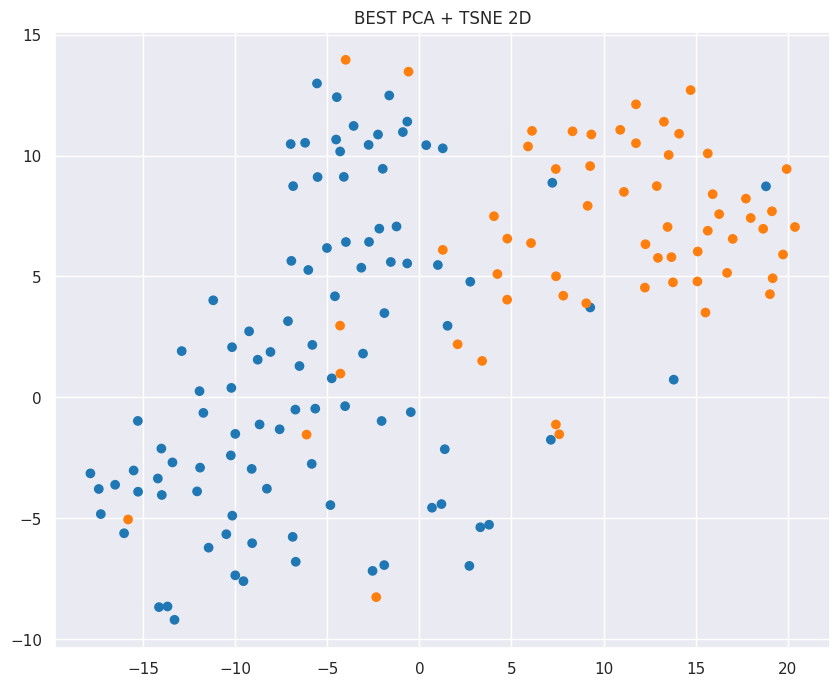

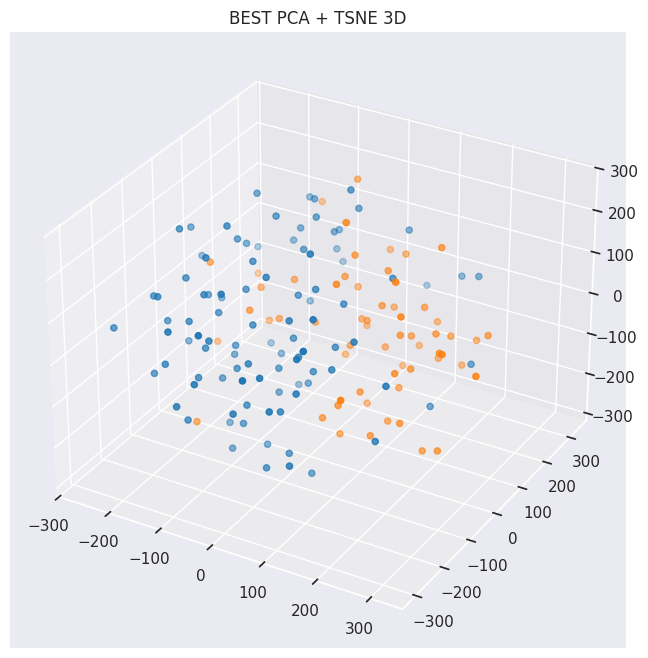

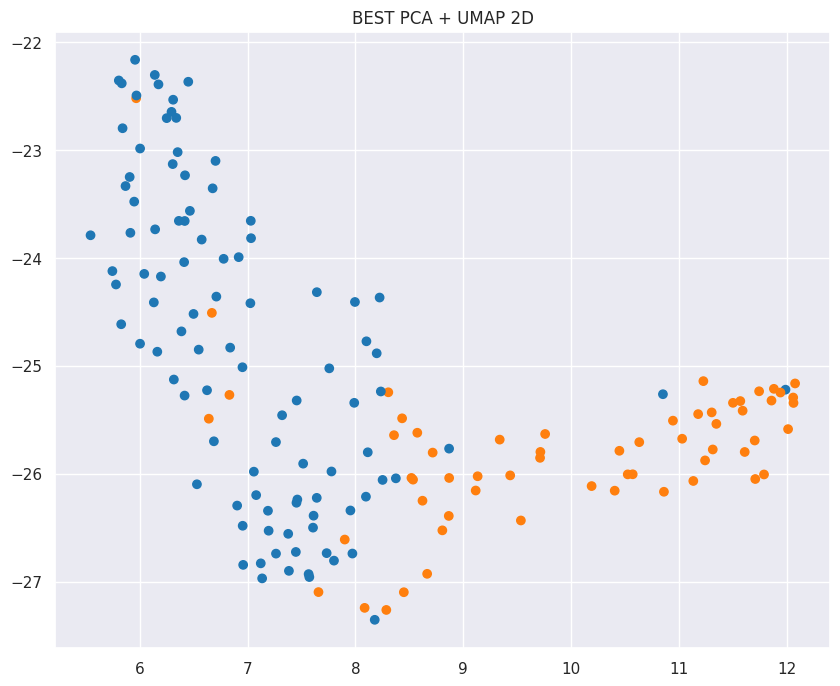

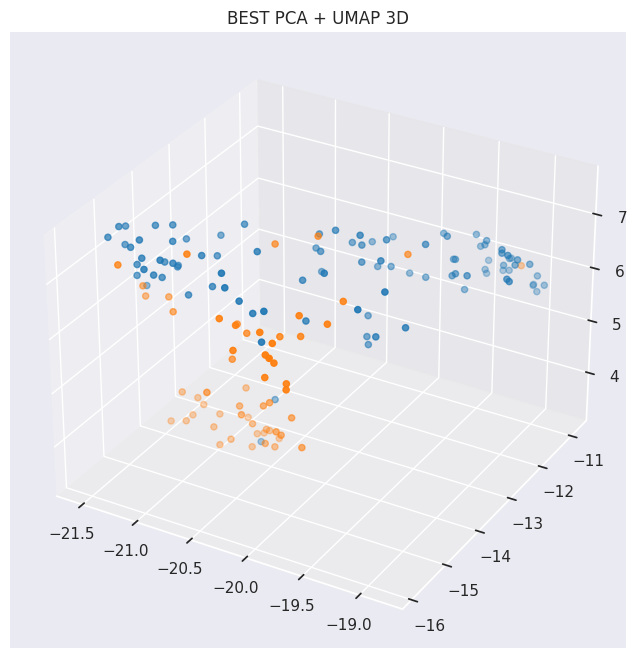

,method,param1_name,param1_value,param2_name,param2_value,score
0,PCA+TSNE,perplexity,5,learning_rate,50.00,0.315209
1,PCA+TSNE,perplexity,5,learning_rate,75.00,0.313224
2,PCA+TSNE,perplexity,5,learning_rate,100.00,0.321287
3,PCA+TSNE,perplexity,5,learning_rate,120.00,0.329095
4,PCA+TSNE,perplexity,5,learning_rate,150.00,0.320098
...,...,...,...,...,...,...
187,PCA+UMAP,n_neighbors,30,min_dist,0.03,0.320226
188,PCA+UMAP,n_neighbors,30,min_dist,0.04,0.230882
189,PCA+UMAP,n_neighbors,30,min_dist,0.05,0.259434
190,PCA+UMAP,n_neighbors,30,min_dist,0.07,0.262302


In [20]:
auto_reduce_and_evaluate(final_df, group_column="gender")